# 0. Import Libraries

In [30]:
import numpy as np
from dataclasses import dataclass
import time
import matplotlib.pyplot as plt

# 1. System Configuration


## Parameters

In [31]:
@dataclass
class SystemConfig:
    sample_rate: float = 1e6      # 取樣率 1 MHz
    symbol_rate: float = 1e5      # 符元率 100 kBaud
    snr_db: float = 30.0          # 訊雜比 (目前 B2B 測試暫不生效)
    payload_text: str = "Hello Satellite! This is a test message from Earth."

## Visualization

In [32]:
class SignalVisualizer:
    """提供通訊系統除錯與分析的靜態繪圖方法"""

    @staticmethod
    def plot_constellation(symbols: np.ndarray, title: str = "QPSK Constellation Diagram"):
        """繪製複數符元的星座圖"""
        # 建立畫布
        plt.figure(figsize=(6, 6))

        # 將複數陣列分離為 I (實部) 與 Q (虛部)
        i_coords = np.real(symbols)
        q_coords = np.imag(symbols)

        # 繪製接收到的訊號點 (Scatter plot)
        plt.scatter(i_coords, q_coords, c='blue', alpha=0.5, s=10, label='Received Symbols')

        # 繪製視覺輔助線：理想的單位圓 (能量為 1)
        circle = plt.Circle((0, 0), 1, color='red', fill=False, linestyle='--', alpha=0.5, label='Unit Power Circle')
        plt.gca().add_patch(circle)

        # 繪製十字座標軸 (Decision Boundaries)
        plt.axhline(0, color='black', linewidth=1, alpha=0.5)
        plt.axvline(0, color='black', linewidth=1, alpha=0.5)

        # 圖表格式設定
        plt.title(title, fontsize=14, fontweight='bold')
        plt.xlabel("In-Phase (I)", fontsize=12)
        plt.ylabel("Quadrature (Q)", fontsize=12)
        plt.grid(True, linestyle=':', alpha=0.7)
        plt.axis('equal')  # 關鍵：確保 I 和 Q 軸比例一致，圓形才不會變橢圓
        plt.xlim(-1.5, 1.5)
        plt.ylim(-1.5, 1.5)
        plt.legend(loc='upper right')

        # 顯示圖表
        plt.tight_layout()
        plt.show()

# 2. System Modules


## Transmitter

### QPSK Modulator

In [33]:
class QPSKModulator:
    def __init__(self):
        # 定義 QPSK 星座圖 (使用 Gray Code)
        # 位元對應: '00' ->  1 + 1j
        #         '01' -> -1 + 1j
        #         '11' -> -1 - 1j
        #         '10' ->  1 - 1j
        # 乘以 1/sqrt(2) 進行能量正規化
        self.normalization_factor = 1.0 / np.sqrt(2.0)
        self.mapping_table = {
            (0, 0): complex(1, 1)   * self.normalization_factor,
            (0, 1): complex(-1, 1)  * self.normalization_factor,
            (1, 1): complex(-1, -1) * self.normalization_factor,
            (1, 0): complex(1, -1)  * self.normalization_factor
        }

    def process(self, bits: np.ndarray) -> np.ndarray:
        """將 1D 位元陣列轉換為 1D 複數符元陣列"""
        # 確保位元數量是偶數，若不是則補 0
        if len(bits) % 2 != 0:
            bits = np.append(bits, 0)

        # 將位元兩兩分組
        bit_pairs = bits.reshape(-1, 2)

        # 使用 list comprehension 與 mapping table 快速轉換 (向量化替代方案亦可)
        symbols = [self.mapping_table[tuple(pair)] for pair in bit_pairs]
        return np.array(symbols, dtype=np.complex64)

### Transmitter

In [34]:
class Transmitter:
    def __init__(self, config):
        self.config = config
        self.modulator = QPSKModulator() # 加入調變器

    def process(self, text_data: str) -> np.ndarray:
        # 1. 字串轉位元 (Source Coding)
        bits_str = ''.join(format(ord(char), '08b') for char in text_data)
        bits = np.array([int(b) for b in bits_str], dtype=np.int8)

        # 2. 數位調變 (Modulation) -> 輸出複數陣列
        baseband_symbols = self.modulator.process(bits)
        return baseband_symbols

## Channel

In [35]:
class Channel:
    def __init__(self, config):
        self.config = config

    def process(self, tx_signal: np.ndarray) -> np.ndarray:
        """
        模擬真實物理通道：加入基礎的 AWGN (加性高斯白雜訊)
        這會讓星座圖上的點產生散射，模擬真實衛星接收到的訊號狀態。
        """
        # 設定一個隨機的雜訊能量 (目前為硬編碼，僅供視覺化測試)
        noise_variance = 0.05

        # 產生複數高斯雜訊 (I 軸與 Q 軸都要有雜訊)
        noise = np.random.normal(0, np.sqrt(noise_variance/2), len(tx_signal)) + \
                1j * np.random.normal(0, np.sqrt(noise_variance/2), len(tx_signal))

        # 將雜訊疊加到發射訊號上
        rx_signal = tx_signal + noise
        return rx_signal

## Receiver

### QPSK Demodulator

In [36]:
class QPSKDemodulator:
    def __init__(self):
        # 對應的解調邏輯：透過判斷 I 和 Q 的正負號來還原位元
        pass

    def process(self, symbols: np.ndarray) -> np.ndarray:
        """將複數符元還原為位元陣列 (Hard Decision)"""
        bits = np.zeros(len(symbols) * 2, dtype=np.int8)

        # 判斷 I (實部)
        # I > 0 代表 bit 0 是 0 (對應 1-1j 或 1+1j)
        # I < 0 代表 bit 0 是 1 (對應 -1+1j 或 -1-1j)
        bits[0::2] = (np.real(symbols) < 0).astype(np.int8)

        # 判斷 Q (虛部)
        # 根據我們的 mapping:
        # 實部 > 0 時，虛部 > 0 -> (0,0), 虛部 < 0 -> (1,0)  [這裡需特別處理 Gray code 的反向映射]
        # 更簡單且強健的硬體判決寫法如下：

        # I 通道判決
        bits[0::2] = np.where(np.real(symbols) > 0, 0, 1)
        # Q 通道判決 (觀察 Mapping: I=1,Q=1->00; I=-1,Q=1->01. 發現只要 Q>0，第二個 bit 就是 0 嗎？不是。)
        # 讓我們直接用距離最小化 (Minimum Distance) 來做，這樣最不容易出錯，且適用於任何星座圖。

        # 重建 mapping table keys 與 values
        mapping_keys = np.array([[0, 0], [0, 1], [1, 1], [1, 0]])
        norm = 1.0 / np.sqrt(2.0)
        mapping_vals = np.array([1+1j, -1+1j, -1-1j, 1-1j]) * norm

        demodulated_bits = []
        for sym in symbols:
            # 計算接收符元與 4 個理想星座點的歐幾里得距離
            distances = np.abs(sym - mapping_vals)
            # 找出距離最近的索引
            min_index = np.argmin(distances)
            demodulated_bits.extend(mapping_keys[min_index])

        return np.array(demodulated_bits, dtype=np.int8)

### Receiver

In [37]:
class Receiver:
    def __init__(self, config):
        self.config = config
        self.demodulator = QPSKDemodulator() # 加入解調器

    def process(self, rx_symbols: np.ndarray) -> str:
        # 1. 數位解調 (Demodulation)
        bits = self.demodulator.process(rx_symbols)

        # 2. 位元轉字串 (Source Decoding)
        chars = []
        # 確保我們只取 8 的倍數
        valid_length = (len(bits) // 8) * 8
        for i in range(0, valid_length, 8):
            byte_val = int("".join(str(b) for b in bits[i:i+8]), 2)
            chars.append(chr(byte_val))

        return "".join(chars)

# 3. Testbench Runner


In [38]:
class EndToEndTestbench:
    def __init__(self, config):
        self.config = config
        self.tx = Transmitter(config)
        self.channel = Channel(config)
        self.rx = Receiver(config)

    def run_b2b_test(self):
        print(f"--- 啟動 Back-to-Back 系統測試 ---")

        # 為了讓星座圖點數夠多比較好看，我們輸入長一點的字串
        test_payload = "Satellite communications rely on complex signal processing. " * 5
        print(f"[Input] 傳送字元數: {len(test_payload)} chars")

        start_time = time.time()

        # 1. 發射端處理 (字串 -> 位元 -> QPSK 複數符元)
        tx_symbols = self.tx.process(test_payload)

        # 2. 衛星通道 (加入雜訊)
        rx_symbols = self.channel.process(tx_symbols)

        # === [新增] 在解調前，呼叫儀表板繪製星座圖 ===
        print("=> 正在繪製接收端星座圖...")
        SignalVisualizer.plot_constellation(rx_symbols, "RX Constellation (with AWGN Noise)")

        # 3. 接收端處理 (QPSK 複數符元 -> 位元 -> 字串)
        recovered_text = self.rx.process(rx_symbols)

        elapsed_time = time.time() - start_time

        # 驗證結果
        print(f"--- 測試完成 (耗時 {elapsed_time:.4f} 秒) ---")
        if test_payload == recovered_text:
            print("=> ✅ 測試通過：完美還原文字！(雜訊在容許範圍內，硬體判決成功)")
        else:
            print("=> ❌ 測試失敗：雜訊過大導致位元錯誤。")

# 4. Execution

--- 啟動 Back-to-Back 系統測試 ---
[Input] 傳送字元數: 300 chars
=> 正在繪製接收端星座圖...


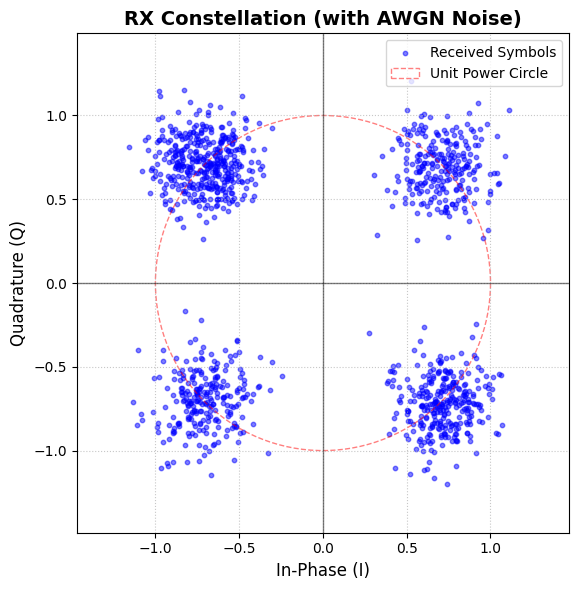

--- 測試完成 (耗時 0.1663 秒) ---
=> ✅ 測試通過：完美還原文字！(雜訊在容許範圍內，硬體判決成功)


In [39]:
config = SystemConfig()
testbench = EndToEndTestbench(config)
testbench.run_b2b_test()